# Assignment 7

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional note:

* You can complete this assignment using either your local machine or Google Colab. Your solution for this assignment should be able to run on the <span style="color:red">FREE version</span> of Google Colab. If you find that you need to upgrade to the paid version, it indicates that there is an inefficiency in your code.
---

#### ``Objectives``
1. Implement a Decision Forest for land cover classification

#### ``Motivation``

Land cover classification using machine learning (ML) techniques is important for several reasons, spanning environmental monitoring, resource management, urban planning, disaster response, and scientific research. 

#### ``Data``

In this assignment, you will use the EuroSAT dataset, consisting of Sentinel-2 RGB satellite images of 10 classes with 27000 labeled and geo-referenced samples. 

The dataset is hosted by [TensorFlow Data Collections](https://www.tensorflow.org/datasets/catalog/eurosat). To avoid any data versioning issues, we have downloaded the data for you (please see below).

`Download` link: [images + labels](https://drive.google.com/file/d/131GuYn092OlWKGopsT8arQoDreneU7SZ/view?usp=share_link). Once you unzip the file, you will see that the name of each subfolder represents the land cover classes.

---

### Import libraries

^ make sure to replace DATA_PATH with the path to the directory where you saved the data.

---
### Step 1: Data ingestion

#### <span style="color:chocolate"> Exercise 1 (10 points) </span>

Let's load the 2D images and their corresponding labels. Implement the <span style="color:chocolate">load_data()</span> function below according to the following guidelines:
- to read label and image names: use the <span style="color:chocolate">os</span> library (in particular the <span style="color:chocolate">os.listdir()</span> and <span style="color:chocolate">os.path.join()</span> methods);
- to load an image: use the <span style="color:chocolate">load_image()</span> method (see list of imported libraries);
- to transform images to arrays: use the <span style="color:chocolate">img_to_array()</span> method (see list of imported libraries).

In [21]:
def load_data(path_to_data):
    '''Load 2D images and their corresponding labels
    Parameters:
    path_to_data (str): This is the path to data
    
    Returns:
    images (np.ndarray): A numpy array of shape (N, 64, 64, 3)
    labels (np.ndarray): A numpy array of shape (N)
    
    '''
    ## load images and labels
    # FILL IN CODE HERE #  

    # First create empty lists - which will be turned into np arrs after loading
    img_list = []
    label_list = []

    # Outer: loop through DATA_PATH - EuroSAT folder
    for f in os.listdir(path_to_data):
        # Inner: for each label folder, loop through the img files
        for i in os.listdir(os.path.join(path_to_data, f)):

            # Load the image and specifying the size
            img = load_img(os.path.join(path_to_data, f, i), 
                           target_size=(64, 64))

            # Convert image file to np arr
            img_arr = img_to_array(img) 

            # Add image and label to the list
            img_list.append(img_arr)
            # Split the image file name twice to get to the label, and convert to lowercase for consistency
            label_list.append(i.split('.')[0].split('_')[0].lower())

    # Convert lists to np arrays
    images = np.array(img_list)
    labels = LabelEncoder().fit_transform(label_list)

#    labels = np.array(label_list)

    return images, labels

In [22]:
# Load images and labels. Print shapes

images, labels = load_data(DATA_PATH)
print("Shape of images ", images.shape)
print("Shape of labels ", labels.shape)

Shape of images  (27000, 64, 64, 3)
Shape of labels  (27000,)


---
### Step 2: Exploratory data analysis (EDA)

#### <span style="color:chocolate"> Exercise 2 (10 points) </span>

Plot the land cover class distribution. Are the classes balanced?

Note: It's acceptable to plot the distribution of classes before splitting your data into training, validation, and test sets. Doing so does not compromise the "blindness" of the test data. Why?

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_data(path_to_data):
    '''Load 2D images and their corresponding labels
    Parameters:
    path_to_data (str): This is the path to data
    
    Returns:
    images (np.ndarray): A numpy array of shape (N, 64, 64, 3)
    labels (np.ndarray): A numpy array of shape (N,)
    label_mapping (dict): Dictionary {int: str} mapping integers back to original labels
    '''
    img_list = []
    label_list = []

    for f in os.listdir(path_to_data):
        for i in os.listdir(os.path.join(path_to_data, f)):
            img = load_img(os.path.join(path_to_data, f, i), target_size=(64, 64))
            img_arr = img_to_array(img)
            img_list.append(img_arr)
            label_list.append(i.split('_')[0].lower())  # Extract label from filename

    images = np.array(img_list)

    # Reconstruct Label Mapping (ensure same ordering as LabelEncoder)
    unique_classes = sorted(set(label_list))  # Alphabetical order like LabelEncoder
    label_mapping = {idx: class_name for idx, class_name in enumerate(unique_classes)}

    # Encode labels to integers
    labels = np.array([unique_classes.index(lbl) for lbl in label_list])

    return images, labels, label_mapping

def plot_label_distribution(y, label_mapping):
    '''Plot the class distribution using original string labels'''
    unique, counts = np.unique(y, return_counts=True)
    
    # Convert integer labels back to original string labels
    class_names = [label_mapping[i] for i in unique]
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(class_names, counts, color="skyblue", edgecolor="black")

    # Formatting
    plt.xlabel("Class Labels", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Class Distribution", fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=10)  # Rotate for clarity
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.show()

# Example Usage
X, y, label_mapping = load_data("path/to/data")
plot_label_distribution(y, label_mapping)


In [8]:
unique_labels = np.unique(labels)  # Unique integer values

unique_classes = sorted(set(i.split('_')[0].lower() for f in os.listdir(DATA_PATH) for i in os.listdir(os.path.join(DATA_PATH, f))))

# Create a dictionary mapping integer labels back to class names
label_mapping = dict(zip(unique_labels, unique_classes))
label_mapping

{np.int64(0): 'annualcrop',
 np.int64(1): 'forest',
 np.int64(2): 'herbaceousvegetation',
 np.int64(3): 'highway',
 np.int64(4): 'industrial',
 np.int64(5): 'pasture',
 np.int64(6): 'permanentcrop',
 np.int64(7): 'residential',
 np.int64(8): 'river',
 np.int64(9): 'sealake'}

In [ ]:
labels.shape
labels
label_mapping[4]
unique_classes 

#[label_mapping[i] for i in np.unique(labels)]


['annualcrop',
 'forest',
 'herbaceousvegetation',
 'highway',
 'industrial',
 'pasture',
 'permanentcrop',
 'residential',
 'river',
 'sealake']

In [19]:
unique_labels, counts = np.unique(labels, return_counts=True)
counts

class_names = [label_mapping[i] for i in unique_labels]

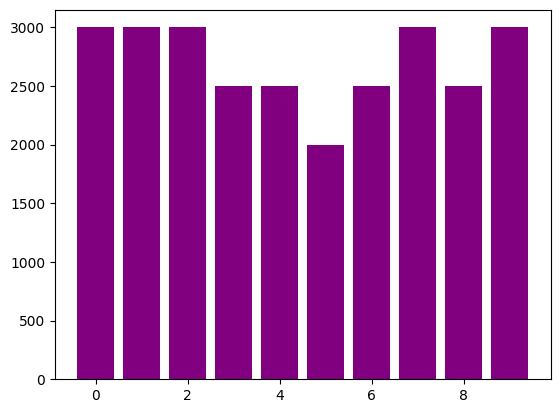

In [20]:
# FILL IN CODE HERE # 


fig, ax = plt.subplots()

ax.bar(unique_labels,counts,
       color='purple')


plt.show()

Comment on class balance: [YOUR ANSWER HERE]

#### <span style="color:chocolate"> Exercise 3 (10 points) </span>

Inspect (print) one image from each class. What land classes do you think a Decision Tree classifier is more likely to confuse?

In [ ]:
# FILL IN CODE HERE #

Most confused land classes: [YOUR ANSWER HERE]

---
### Step 3: Data preprocessing

Encode labels

In [ ]:
encoder = LabelEncoder().fit(list(set(labels))) # fit on unique labels
encoded_labels = encoder.transform(labels) # apply to labels array (will get labels from 0 to 9)
encoded_labels_classes = list(encoder.classes_) # store mapping generated by the encoder

#### <span style="color:chocolate"> Exercise 4 (10 points) </span>

Create train, validation, and test data. Implement the <span style="color:chocolate">split_data()</span> function below according to the following guidelines:
- shuffle images and labels before spliting the data;
- use a 60/20/20 split.

In [ ]:
def split_data(images, labels, split):
    '''Split data into train, validation and test sets.
    
    Parameters:
    images  (np.ndarray): Images of shape (N, 64, 64, 3)
    labels (np.ndarray): Labels of shape (N,)   
    split (tuple): 3 values summing to 1 defining split of train, validation and test sets
    
    Returns:
    X_train (np.ndarray): Train images of shape (N_train, 64, 64, 3)
    y_train (np.ndarray): Train labels of shape (N_train,)
    X_val (np.ndarray): Val images of shape (N_val, 64, 64, 3)
    y_val (np.ndarray): Val labels of shape (N_val,)
    X_test (np.ndarray): Test images of shape (N_test, 64, 64, 3)
    y_test (np.ndarray): Test labels of shape (N_test,)
    
    '''
    # NOTE: Each time you run this cell, you'll re-shuffle the data. The ordering will be the same due to the random seed generator 
    tf.random.set_seed(1234)
    np.random.seed(1234)
    
    # shuffle data
    # FILL IN CODE HERE #
    
    # create data splits
    # FILL IN CODE HERE #
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [ ]:
# define splits
split = (0.6, 0.2, 0.2)

# create train, val, test sets
X_train, y_train, X_val, y_val, X_test, y_test = split_data(images, encoded_labels, split)

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)

print('Shape of val images ', X_val.shape)
print('Shape of train labels ', y_val.shape)

print('Shape of test images ', X_test.shape)
print('Shape of test labels ', y_test.shape)

#### <span style="color:chocolate"> Exercise 5 (10 points) </span>

Perform image transformation and augmentation. 

<span style="color:green"> Step 1: </span> Implement the <span style="color:chocolate">data_preprocessing()</span> function below according to the following guidelines:

- Applied on training set only: 
    - create additional copies of the training images by applying the following augmentation techniques to each image: adjust brightness by adding DELTA=0.3 to the pixel values, then adjust contrast to CONTRAST_FACTOR=3, then flip left right (Hint: use the methods available in the tf.image module);
    - concatenate the augmented images to the original training images. Note that the train set should be double in size after data augmentation, i.e., 32400 images and labels;
    
    
- Applied on training, validation, and test sets: normalize all pixel values by dividing by 255.0.
    
<span style="color:green"> Step 2: </span> Comment on the importance of adding augmented images to training data (be sure to justify why you don't augment the validation and test sets as well).

In [ ]:
def data_preprocessing(X, y, data_partition='train'):
    '''Apply transformations and augmentations to training, validation, and test dat;
    
    Parameters:
    X  (np.ndarray): Images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)   
    data_partition (str): "train"
    
    Returns:
    X (np.ndarray): Preprocessed images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)
    
    '''

    CONTRAST_FACTOR = 3
    DELTA = 0.3
    
    # image augmentation on training data
    if data_partition=="train":
        # adjust brightness
        X_augm = '' # FILL IN CODE HERE #

        # adjust contrast
        X_augm = '' # FILL IN CODE HERE #

        # random flip
        X_augm = '' # FILL IN CODE HERE #

        # concatenate original X and augmented X_aug data
        X = '' # FILL IN CODE HERE #

        # concatenate y_train (note the label is preserved)
        y_augm = y
        y = tf.concat([y, y_augm],axis=0)

        # shuffle X and y, i.e., shuffle two tensors in the same order
        shuffle = tf.random.shuffle(tf.range(tf.shape(X)[0], dtype=tf.int32))
        X = tf.gather(X, shuffle).numpy() # transform X back to numpy array instead of tensor
        y = tf.gather(y, shuffle).numpy() # transform y back to numpy array instead of tensor
        
        
    # rescale image by dividing each pixel by 255.0 
    # FILL IN CODE HERE #
    
    return X, y

Comment on the importnace of adding augmented images to training data (be sure to justify why you don't augment the validation and test sets as well): [YOUR ANSWER HERE]

In [ ]:
# apply data preprocessing
X_train, y_train = data_preprocessing(X_train, y_train, data_partition='train')
X_val, y_val = data_preprocessing(X_val, y_val, data_partition='val')
X_test, y_test = data_preprocessing(X_test, y_test, data_partition='val')

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val.shape)
print('Shape of test images ', X_test.shape)

Reshape training, val, and test data (to be compatible with sklearn Decision Forests)

In [ ]:
# compute number of features (multiply RGB features)
features_shape = X_train[:, :, :, 0].shape[1] * X_train.shape[2] * X_train.shape[3]
print('Total number of features used for Decision Forests', features_shape)

# reshape data
X_train_re = X_train.reshape(X_train.shape[0], features_shape)
X_val_re = X_val.reshape(X_val.shape[0], features_shape)
X_test_re = X_test.reshape(X_test.shape[0], features_shape)

# print shapes
print('Shape of train images ', X_train_re.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val_re.shape)
print('Shape of test images ', X_test_re.shape)

---
### Step 4: Modeling

#### <span style="color:chocolate"> Exercise 6 (10 points) </span>

Implement a Decision Forest classifier according to the following guidelines (let's call this model our baseline classifier):
    
- Use the <span style="color:chocolate">RandomForestClassifier</span> class available in the <span style="color:chocolate">sklearn.ensemble</span> module;
- Set the following argument values:
    - n_estimators=2,
    - n_jobs=1
    - random_state=7
    - max_depth=8
- Train the model on (X_train_re, y_train) data;
- Evaluate the accuracy of the model on (X_train_re, y_train) and (X_val_re, y_val) data. Comment on model performance on training vs. validation datasets. Does the model generalize well?
- Plot the confusion matrix using (y_val, y_val_pred) data. Comment on the classes that the model confuses the most.

In [ ]:
### YOUR CODE HERE ###

Comment on model accuracy on training vs. validation data: [YOUR ANSWER HERE]

Does the model generalize well?: [YOUR ANSWER HERE]

Comment on the classes that the model confuses the most: [YOUR ANSWER HERE]

#### <span style="color:chocolate"> Exercise 7 (20 points) </span>

Implement a Decision Forest classifier that improves the training and validation set accuracy performance of the baseline model implemented above by at least 10% (the more you can improve the better). Also, the performance difference between the training and validation sets should be at most 10%. Be sure to follow these guidelines: 
    
- Use the <span style="color:chocolate">RandomForestClassifier</span> or the <span style="color:chocolate">GradientBoostingClassifier</span> available in the <span style="color:chocolate">sklearn.ensemble</span> module
- Be explicit on how your implementation is different compared to the baseline classifier:
    - different argment values for the baseline model (RandomForestClassifier)?
    - different Decision Forest classifier?
    - different data preprocessing procedure?
    - a combination of the three points above
    - anything else?
- Train the model on (X_train_re, y_train) data.
- Evaluate the model's accuracy on (X_val_re, y_val) data. Comment on training vs. validation performance relative to baseline model.
- Plot confusion matrix using the (y_val, y_val_pred) data. Comment on the classes the model confuses the most relative to the baseline.

In [ ]:
rf_clf2 = ''
### YOUR CODE HERE ###

How your implementation is different compared to the baseline classifier: [YOUR ANSWER HERE]

Comment on training vs. validation performance relative to baseline model: [YOUR ANSWER HERE]

Comment on the classes the model confuses the most relative to the baseline: [YOUR ANSWER HERE]

---
### Step 5: Evaluation and Generalization

#### <span style="color:chocolate"> Exercise 8 (2 points) </span>

Report accuracy performance on the test data using the model trained for Exercise 7. How does the test set performance compare with the one reported for the training and validation sets?

In [ ]:
### YOUR CODE HERE ###

Comment on test set accuracy vs. training vs. validation set accuracy:

---
### Step 6: Discussion

#### <span style="color:chocolate"> Exercise 9 (8 points) </span>

Would you recommend a Decision Forest for land cover classification? Why or why not?

In [ ]:
### YOUR ANSWER HERE ###

#### <span style="color:chocolate"> Exercise 10 (10 points) </span>

What other ML model would you propose to improve performance over the Decision Forest classifier you implemented for Exercise 7?

In [ ]:
### YOUR ANSWER HERE ###

----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Implement the idea proposed for Exercise 10. Perform hyperparameter tuning using the training and validation sets, then report the model performance on the test data. Does your model generalize well?

In [ ]:
### YOUR CODE HERE ###